# DecodeLabs Project-2

## Supervised Learning (Fraud Detection)

- __Goals :__ `Classify the model to identify the fraud transactions in highly imbalanced dataset.`

- __Key Requirements :__

    `Impliment SMOTE to handle imbalance data`

    `Train Multiple Algorithms.`

    `Show model Accuracy and evalute precision, recall ...metrices`


- __Key Skills :__ `Classification algorithms`, `handle imbalance data`, `pipelining N HyperParameter tuning.`

### 1. Problem Statement

- This project is based on supervised classification ml learnings

- We need to engineer the FraudTransaction feature.

- Based on data need to handle imbalance data via SMOTE

- Has to Implement classfication algorithms... use pipelines and HyperParameter tuning

- Overall This model based on prediction of FraudTransaction.

##### FraudTransaction records

Based on other features affects we can categories this feature by

- Unusually __High TotalPrice__

- Unusually __High Quantity__

- suspicious PaymentMethod

- Unusual __ItemsInCart__

- Oder Status, CouponUsage and __combination of suspicious records.__

### 2. Data Collection

- Source : project-1 cleaned raw data

    `E:\\Python 2.0\\InternDecodelabs\\project-2\\data\\Project1_cleanedData.csv`

- The Dataset contains 1200 row N 14 column records.

#### 2.1 Import Data N packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
salesData = pd.read_csv("E:\\Python 2.0\\InternDecodelabs\\project-2\\data\\Project1_cleanedData.csv")
salesData

,Date,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CouponSave10,CouponWinter15,CouponFreeship,RevenueGenrated
0,01-01-2023,Monitor,1,410.60,Online,Cancelled,2,WINTER15,Referral,410.600,0.0000,61.5900,0.00,0.000
1,01-01-2023,Monitor,1,318.81,Debit Card,Pending,3,WINTER15,Email,318.810,0.0000,47.8215,0.00,0.000
2,01-01-2023,Chair,2,645.85,Online,Shipped,5,WINTER15,Referral,1291.700,0.0000,193.7550,0.00,0.000
3,01-01-2024,Printer,2,40.23,Credit Card,Cancelled,4,SAVE10,Google,165.012,16.5012,0.0000,0.00,0.000
4,01-01-2024,Chair,3,236.50,Online,Delivered,8,FREESHIP,Email,709.500,0.0000,0.0000,709.50,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,31-08-2024,Monitor,2,552.63,Debit Card,Delivered,7,WINTER15,Instagram,1105.260,0.0000,165.7890,0.00,939.471
1196,31-10-2023,Chair,2,488.90,Cash,Delivered,7,FREESHIP,Facebook,977.800,0.0000,0.0000,977.80,0.000
1197,31-10-2023,Chair,5,191.63,Gift Card,Delivered,6,FREESHIP,Facebook,958.150,0.0000,0.0000,958.15,0.000
1198,31-10-2023,Chair,4,298.36,Debit Card,Pending,8,FREESHIP,Google,1193.440,0.0000,0.0000,1193.44,0.000


In [3]:
salesData.shape

(1200, 14)

In [4]:
salesData.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,CouponSave10,CouponWinter15,CouponFreeship,RevenueGenrated
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1017.199833,33.603366,49.028504,354.309482,109.786191
std,1.407557,197.177146,2.281983,718.857695,62.955304,94.293963,644.383072,366.042021
min,1.000000,11.390000,1.000000,165.012000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,186.062500,4.000000,410.520000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,364.210000,5.000000,823.615000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,521.570000,7.000000,1578.475000,38.375500,49.065375,457.397500,0.000000
max,5.000000,699.930000,10.000000,2332.082000,233.208200,349.812300,2332.082000,2098.873800


#### 2.2 Data Information

- No missing values, null values or outliers existed in Data... the raw data is cleaned.

- Products : sales products are __[ Monitor, Chair, Laptop, Tablet, Phone, Printer, Desk ]__ Mostly contains student accessory items.

- Unit Price : products saling price start from __11.39$ to 699.93$__.

- Order Status : __[ Cancelled, Pending, Shipped, Delivered, Returned]__.

    Only in Delivered status of order's price be counted on Revenue.

- Based on Data analysis all products are in stock.

- Coupon Code :
    
    `SAVE10 - contains 10% of totalprice.`

    `WINTER15 - contains 15% of totalprice.`

    `FREESHIP - contains 100% of totalprice`

    The totalRevenue is minused with any coupon discount existed.

- __Average GenratedRevenue is 109.8$__

- __Maximum 366$ N minimum 2098.9$ Revenue Genrated.__

### 3. Target FraudTransaction Feature Engineering

- Engineer the new feature based on Dataset That leads conclusion of it's FraudTransaction or not ???

In [5]:
### Senarios where Transaction can be conclude to Fraud
# if 
# totalprice > 95%ile 
# unit price > 95%ile
# itemsIncart > 9 and quantity > 5 
# any of two are True then it's Fraud Transaction

Fraudprice = salesData['TotalPrice'].quantile(0.95)
Fraudunits = salesData['UnitPrice'].quantile(0.95)
FraudQuantity = salesData["Quantity"].max() - salesData["Quantity"].min()
FraudCart = salesData["ItemsInCart"].max() - salesData["ItemsInCart"].min()

FraudCart, Fraudprice, FraudQuantity, Fraudunits

(np.int64(9), np.float64(2332.082), np.int64(4), np.float64(660.7214999999999))

In [6]:
salesData["FraudTransaction"] = salesData.apply(
    lambda x:1 
    if ( (x['TotalPrice'] > Fraudprice) +
        (x['UnitPrice'] > Fraudunits) +
        (x['Quantity'] > FraudQuantity+2) +
        (x['ItemsInCart'] > FraudCart)) >=1
        else 0, axis = 1
)

In [7]:
salesData

,Date,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CouponSave10,CouponWinter15,CouponFreeship,RevenueGenrated,FraudTransaction
0,01-01-2023,Monitor,1,410.60,Online,Cancelled,2,WINTER15,Referral,410.600,0.0000,61.5900,0.00,0.000,0
1,01-01-2023,Monitor,1,318.81,Debit Card,Pending,3,WINTER15,Email,318.810,0.0000,47.8215,0.00,0.000,0
2,01-01-2023,Chair,2,645.85,Online,Shipped,5,WINTER15,Referral,1291.700,0.0000,193.7550,0.00,0.000,0
3,01-01-2024,Printer,2,40.23,Credit Card,Cancelled,4,SAVE10,Google,165.012,16.5012,0.0000,0.00,0.000,0
4,01-01-2024,Chair,3,236.50,Online,Delivered,8,FREESHIP,Email,709.500,0.0000,0.0000,709.50,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,31-08-2024,Monitor,2,552.63,Debit Card,Delivered,7,WINTER15,Instagram,1105.260,0.0000,165.7890,0.00,939.471,0
1196,31-10-2023,Chair,2,488.90,Cash,Delivered,7,FREESHIP,Facebook,977.800,0.0000,0.0000,977.80,0.000,0
1197,31-10-2023,Chair,5,191.63,Gift Card,Delivered,6,FREESHIP,Facebook,958.150,0.0000,0.0000,958.15,0.000,0
1198,31-10-2023,Chair,4,298.36,Debit Card,Pending,8,FREESHIP,Google,1193.440,0.0000,0.0000,1193.44,0.000,0


In [8]:
salesData["FraudTransaction"].value_counts(normalize=True)*100

FraudTransaction
0    91.25
1     8.75
Name: proportion, dtype: float64

### 4. Handle Imbalanced Data 

- Bias

    Majority class (91% data False) - prediction high(Recall) ...ml learning high

    Minority class (9% data True) - predicion low(Recall) ...ml learning low

- Accuracy : `Actual - True`

    __But prediction is False --> still Accuracy is 90%.__

    Predicting Fraud value (True) records are more important than accuracy.

Drop Categorical records N define x, y

In [9]:
x = salesData.drop(columns=['FraudTransaction', 'ReferralSource', 'CouponCode', 'OrderStatus', 'PaymentMethod', 'Product', 'Date'])
y = salesData['FraudTransaction']

In [10]:
x

,Quantity,UnitPrice,ItemsInCart,TotalPrice,CouponSave10,CouponWinter15,CouponFreeship,RevenueGenrated
0,1,410.60,2,410.600,0.0000,61.5900,0.00,0.000
1,1,318.81,3,318.810,0.0000,47.8215,0.00,0.000
2,2,645.85,5,1291.700,0.0000,193.7550,0.00,0.000
3,2,40.23,4,165.012,16.5012,0.0000,0.00,0.000
4,3,236.50,8,709.500,0.0000,0.0000,709.50,0.000
...,...,...,...,...,...,...,...,...
1195,2,552.63,7,1105.260,0.0000,165.7890,0.00,939.471
1196,2,488.90,7,977.800,0.0000,0.0000,977.80,0.000
1197,5,191.63,6,958.150,0.0000,0.0000,958.15,0.000
1198,4,298.36,8,1193.440,0.0000,0.0000,1193.44,0.000


In [11]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1195    0
1196    0
1197    0
1198    0
1199    0
Name: FraudTransaction, Length: 1200, dtype: int64

#### 1. Undersampling

- Undersample the majority class data

- Take the exactly same n(data points) that balance the minority class data

In [12]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

### Train Test Split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.25, random_state=42)

### Applying Random sampling
rus = RandomUnderSampler(random_state=42)
rusXresample, rusYresample = rus.fit_resample(xtrain, ytrain)

- Balanced Data points 

In [13]:
rusXresample.shape, rusYresample.shape

((176, 8), (176,))

In [14]:
rusYresample.value_counts()

FraudTransaction
0    88
1    88
Name: count, dtype: int64

- Train the model on resampled data

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

classifier_rus = LogisticRegression(class_weight={0:1, 1:8}, random_state=42, max_iter=200)
classifier_rus.fit(rusXresample, rusYresample)

ypred = classifier_rus.predict(xtest)

print(classification_report(ytest, ypred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.76      0.86       283
           1       0.20      1.00      0.33        17

    accuracy                           0.77       300
   macro avg       0.60      0.88      0.60       300
weighted avg       0.95      0.77      0.83       300



Advantage :
- Reduction in bias --> balance the both data points
- Fast training

Disadvantage :
- Information or data loss leads underfitting
- Sampling Bias

#### 2. OverSampling

- Oversample the minority class data

- Duplicates the data points of minority class to balance with majority

In [16]:
from imblearn.over_sampling import RandomOverSampler

### Applying Random Over sampling
ros = RandomOverSampler(random_state=42)
rosXresample, rosYresample = ros.fit_resample(xtrain, ytrain)

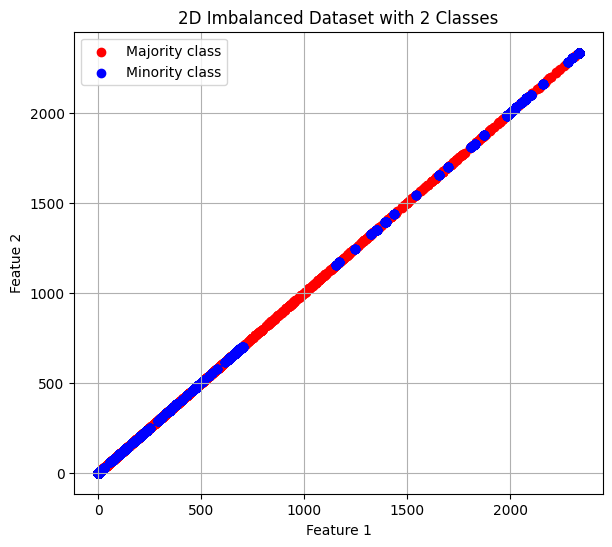

In [17]:
### plotting on x_resample, y_resample
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 2)
plt.scatter(rosXresample[rosYresample == 0], rosXresample[rosYresample ==0], color='red', label='Majority class')

plt.scatter(rosXresample[rosYresample == 1], rosXresample[rosYresample == 1], color='blue', label='Minority class')

plt.title("2D Imbalanced Dataset with 2 Classes")
plt.xlabel("Feature 1")
plt.ylabel("Featue 2")
plt.legend()
plt.grid(True)
plt.show()


- Balanced Data points 

In [18]:
rosXresample.shape, rosYresample.shape

((1624, 8), (1624,))

In [19]:
rosYresample.value_counts()

FraudTransaction
0    812
1    812
Name: count, dtype: int64

- Train the model on OverSample Data

Advantages :

- Reduced Bias

Disadvantages :

- Increase size
- Duplication of data may cause overfitting

#### 3. SMOTE (Synthetic Minority Oversampling Technique)

- Upscaling minority class via genrating new minority data

- Train a KNN on minority class --> finds it's at least 5 closest neighour points

- select any minority points and find KNN

- take a factor b/w [0 - 1]

- New Minority Point : Original - Factor*(Original - Neighbour)

- Do genrates untill both class data balance

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)
smoteXresample, smoteYresample = smote.fit_resample(xtrain, ytrain)

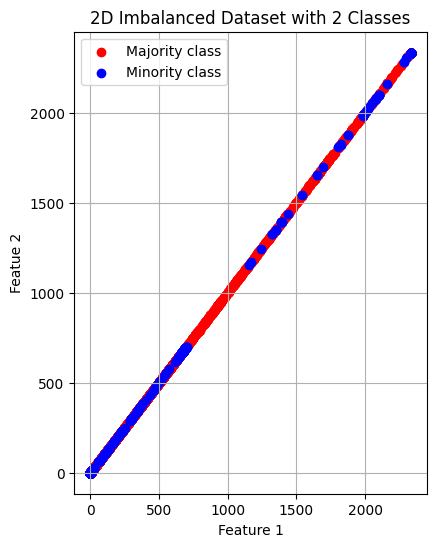

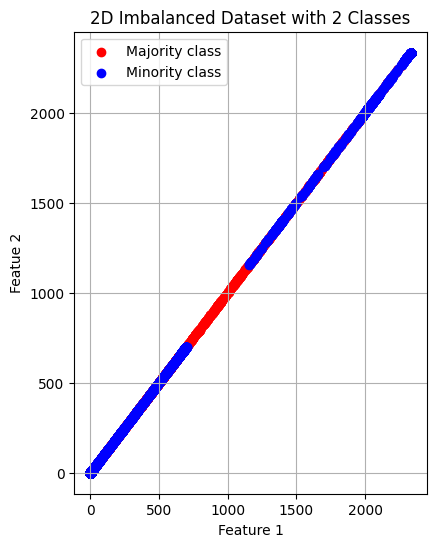

In [21]:
### ploting on xtrain, ytrain
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)

plt.scatter(xtrain[ytrain == 0], xtrain[ytrain==0], color='red', label='Majority class')

plt.scatter(xtrain[ytrain == 1], xtrain[ytrain == 1], color='blue', label='Minority class')

plt.title("2D Imbalanced Dataset with 2 Classes")
plt.xlabel("Feature 1")
plt.ylabel("Featue 2")
plt.legend()
plt.grid(True)
plt.show()


### plotting on x_resample, y_resample
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 2)
plt.scatter(x = smoteXresample[smoteYresample == 0], y = smoteXresample[smoteYresample ==0], color='red', label='Majority class')

plt.scatter(x = smoteXresample[smoteYresample == 1], y = smoteXresample[smoteYresample == 1], color='blue', label='Minority class')

plt.title("2D Imbalanced Dataset with 2 Classes")
plt.xlabel("Feature 1")
plt.ylabel("Featue 2")
plt.legend()
plt.grid(True)
plt.show()


In [22]:
smoteXresample.shape, smoteYresample.shape

((1624, 8), (1624,))

In [23]:
smoteYresample.value_counts()

FraudTransaction
0    812
1    812
Name: count, dtype: int64

Advantages :

- Reduced Bias

- No duplicates so no overfitting

Disadvantages :

- Does not handle categorical data

- Computational Complexity

- Choise of neighbours default we takes k = 5

- Can genrates outliers

- Does the genrated data matches the actual

#### 4. Ensemble Methods

- It based on Balanced randomForset concepts.

- In sampling we take equal data points then train them on first model

    then other remaining data the process repeats with same minority data and new model.

- Then combine all the models the aggrigats will be on balanced data.

#### 5. Class wieght

- It is common feature that exist most of models 

- In this we give more priority wieght on minority data So model should learn more when it occurs

- i. e. LogisticRegression( class_wieght = {0:1, 1:10} )

        Here we give 10 times priority to True value (1) and 1 times priority to False (0)

In [24]:
from imblearn.ensemble import BalancedRandomForestClassifier

Rfc = BalancedRandomForestClassifier(class_weight={0:1, 1:10}, random_state=42)
Rfc.fit(xtrain, ytrain)

### No need to resample normal train model 
RfcYpred = Rfc.predict(xtest)
print(classification_report(ytest, RfcYpred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       283
           1       1.00      1.00      1.00        17

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



### 5. Pipeline - make preprocessing easy

- Missing values via Imputation
- One hot encoding
- Standard Scalling
- Feature selection 
- Data Train

        Pipeline Create and Train model
        Cross validate N GridSearch CV

In [25]:
smoteXresample.head()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,CouponSave10,CouponWinter15,CouponFreeship,RevenueGenrated
0,4,224.61,6,898.440,0.0,134.7660,0.000,0.0
1,2,103.41,2,206.820,0.0,0.0000,206.820,0.0
2,5,73.83,9,369.150,0.0,0.0000,369.150,0.0
3,3,46.11,5,165.012,0.0,24.7518,0.000,0.0
4,4,652.48,5,2332.082,0.0,0.0000,2332.082,0.0


In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import chi2, SelectKBest, f_classif
from sklearn.pipeline import Pipeline, make_pipeline

smoteXresample

,Quantity,UnitPrice,ItemsInCart,TotalPrice,CouponSave10,CouponWinter15,CouponFreeship,RevenueGenrated
0,4,224.610000,6,898.440000,0.000000,134.766000,0.000,0.000000
1,2,103.410000,2,206.820000,0.000000,0.000000,206.820,0.000000
2,5,73.830000,9,369.150000,0.000000,0.000000,369.150,0.000000
3,3,46.110000,5,165.012000,0.000000,24.751800,0.000,0.000000
4,4,652.480000,5,2332.082000,0.000000,0.000000,2332.082,0.000000
...,...,...,...,...,...,...,...,...
1619,4,663.049758,8,2332.082000,233.208200,0.000000,0.000,0.000000
1620,4,492.216904,9,2332.082000,233.208200,0.000000,0.000,0.000000
1621,5,615.373495,10,2332.082000,0.000000,0.000000,2332.082,0.000000
1622,1,676.506707,3,676.506707,67.650671,0.000000,0.000,0.000000


- `Imputation`

In [27]:
trform1 = ColumnTransformer([
    ("imputeNumer", SimpleImputer(strategy="median"), [1, 3, 7])], 
    remainder="passthrough")

- `OneHotEncoding`

    No categorical columns exist

In [28]:
# trform2 = ColumnTransformer([
#     ("OneHotEncode", OneHotEncoder(sparse_output=False), cfeatures)
# ], remainder="passthrough")

- `Scalling`

In [29]:
trform3 = ColumnTransformer([
    ("StandardScaler", StandardScaler(), [1, 3, 7])
    ])

In [30]:
trform3

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('StandardScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""

- __Best columns record__

        k --> remainder records

In [31]:
trform4 = SelectKBest(score_func=f_classif, k = 3)


In [32]:
trform4

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...0015D2ACBA0C0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",3


- `Train the model`

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
trform5 = BalancedRandomForestClassifier(class_weight={0:1, 1:10}, random_state=42)

#### Create pipeline

In [34]:
pipe = Pipeline([
    ("trf1", trform1),
    # ("trf2", trform2),
    ("trf3", trform3),
    ("trf4", trform4),
    # ("trf5", trform5)
])

- `Or via make_pipeline`

In [35]:
# pipe = make_pipeline(trform1, trform3, trform4, Rfc)

In [36]:
### Display the structure
from sklearn import set_config
set_config(display="diagram")

pipe.fit_transform(smoteXresample, smoteYresample)

array([[-0.50404558,  0.52702012, -0.57726701],
       [-1.35676248, -0.8726212 , -0.30919241],
       [-1.15662146,  1.22684078, -0.09878457],
       ...,
       [ 1.2635302 ,  1.22684078,  2.44551585],
       [-0.77767311, -1.57244187, -0.57726701],
       [ 1.21424695,  0.52702012, -0.57726701]], shape=(1624, 3))

`We use fit_tranform on pipeline becoz it's not trained on any model yet unlesss we can direcctly fit it.`

#### Pipeline Explore

In [37]:
pipe.named_steps["trf1"].transformers_

[('imputeNumer', SimpleImputer(strategy='median'), [1, 3, 7]),
 ('remainder',
  FunctionTransformer(accept_sparse=True, check_inverse=False,
                      feature_names_out='one-to-one'),
  [0, 2, 4, 5, 6])]

In [38]:
pipe.named_steps["trf3"].transformers_

[('StandardScaler', StandardScaler(), [1, 3, 7]),
 ('remainder', 'drop', [0, 2, 4, 5, 6])]

### 6. Train the pipeline on multiple models

- Import models and features performences score
- Train and predict models in loop
- Apply some hyper parameter tuninigs

In [39]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score, roc_curve

In [40]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree Classifier":DecisionTreeClassifier(),
    "Random Forest Classifier":RandomForestClassifier(),
    "Ada Boost Classifier":AdaBoostClassifier(),
    "Gradient Boosting Classifier":GradientBoostingClassifier(),
    #"SVR": SVR(), Not applied
    "K Neighbors Classifier":KNeighborsClassifier()
}

for i in range(len(list(models))):

    model = list(models.values())[i]

    ### fit the models
    model.fit(smoteXresample, smoteYresample)

    ### predict via trained model
    yTrainPred = model.predict(smoteXresample)
    yTestPred = model.predict(xtest)


    ### Performence for trained Ypred
    trained_accuracy = accuracy_score(smoteYresample, yTrainPred)
    trained_f1 = f1_score(smoteYresample, yTrainPred, average="weighted")
    trained_precision = precision_score(smoteYresample, yTrainPred)
    trained_recall = recall_score(smoteYresample, yTrainPred)
    trained_rou_auc = roc_auc_score(smoteYresample, yTrainPred)

    ### Performence for test Ypred
    test_accuracy = accuracy_score(ytest, yTestPred)
    test_f1 = f1_score(ytest, yTestPred, average="weighted")
    test_precision = precision_score(ytest, yTestPred)
    test_recall = recall_score(ytest, yTestPred)
    test_rou_auc = roc_auc_score(ytest, yTestPred)

    print('='*60)
    print('\n')
    print(list(models.keys())[i], "\n\n")

    print("Model performence on tested ypred : ")
    print(f"- Trained Accuracy : {trained_accuracy:.4f}")
    print(f"- Trained f1_score : {trained_f1:.4f}")
    print(f"- Trained precision : {trained_precision:.4f}")
    print(f"- Trained rou auc : {trained_rou_auc:.4f}")


    print("----------------------------------------------------------")

    print("Model performence on trained ypred : ")
    print(f"- Test Accuracy : {test_accuracy:.4f}")
    print(f"- Test f1_score : {test_f1:.4f}")
    print(f"- Test precision : {test_precision:.4f}")
    print(f"- Test rou auc : {test_rou_auc:.4f}")

    print('\n\n')



Logistic Regression 


Model performence on tested ypred : 
- Trained Accuracy : 0.8461
- Trained f1_score : 0.8457
- Trained precision : 0.8164
- Trained rou auc : 0.8461
----------------------------------------------------------
Model performence on trained ypred : 
- Test Accuracy : 0.8600
- Test f1_score : 0.8931
- Test precision : 0.2881
- Test rou auc : 0.9258





Decision Tree Classifier 


Model performence on tested ypred : 
- Trained Accuracy : 1.0000
- Trained f1_score : 1.0000
- Trained precision : 1.0000
- Trained rou auc : 1.0000
----------------------------------------------------------
Model performence on trained ypred : 
- Test Accuracy : 0.9767
- Test f1_score : 0.9785
- Test precision : 0.7083
- Test rou auc : 0.9876





Random Forest Classifier 


Model performence on tested ypred : 
- Trained Accuracy : 1.0000
- Trained f1_score : 1.0000
- Trained precision : 1.0000
- Trained rou auc : 1.0000
----------------------------------------------------------
Model per

#### Performence Metrices

- __Output (y) | Predicted (ypred)__
    
    __Y (actual)__

        1   0

    `1|TP      FP|`

    `0|FN      TN|`

    __Ypred (predicted)__

- __Accuracy : (1, 1) N (0, 0)__

        = TP + TN / TP + FP + FN + TN

- __Precision : Focus on FP (0, 1)__
        
        = TP / TP + FP

- __Recall : Focus on FN (1, 0)__

        = TP / TP + FN

- __ROC AUC : Area under the curve for TP N FP__

### 7. Hyper Parameter tuning and Cross Validate

In [41]:
from sklearn.model_selection import RandomizedSearchCV

# Define a wide search space
random_grid = {
    'n_estimators': [300, 200],
    'max_features': ['sqrt'],
    'max_depth': [None] + [50, 100],
    'min_samples_split': [5],
    'min_samples_leaf': [2],
    'bootstrap': [False]
}

rfc = RandomForestClassifier(random_state=42)

# Sample 50 random combinations across 3-fold cross-validation
rfc_random = RandomizedSearchCV(
    estimator=rfc, 
    param_distributions=random_grid, 
    n_iter=50, 
    cv=3, 
    verbose=1, 
    random_state=42, 
    n_jobs=-1
)

rfc_random.fit(smoteXresample, smoteYresample)
print("Best Parameters:", rfc_random.best_params_)


e:\Python 2.0\myvenv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=50. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}


In [42]:
pipeYpred = rfc_random.predict(xtest)

print(f"accuracy- {accuracy_score(ytest, pipeYpred)}")
print(f"f1 score- {f1_score(ytest, pipeYpred)}")
print(f"precision- {precision_score(ytest, pipeYpred)}")
print(f"recall- {recall_score(ytest, pipeYpred)}")
print(f"roc auc score- {roc_auc_score(ytest, pipeYpred)}")

accuracy- 0.9866666666666667
f1 score- 0.8947368421052632
precision- 0.8095238095238095
recall- 1.0
roc auc score- 0.9929328621908128


In [43]:
print(f"Confusion matrix : {confusion_matrix(ytest, pipeYpred)}")

print("\n")

print(f"TP : {confusion_matrix(ytest, pipeYpred)[0][0]}")

print(f"FP : {confusion_matrix(ytest, pipeYpred)[0][1]}")

print(f"FN : {confusion_matrix(ytest, pipeYpred)[1][0]}")

print(f"TN : {confusion_matrix(ytest, pipeYpred)[1][1]}")

print('\n')

print("classification report : \n", classification_report(ytest, pipeYpred))

Confusion matrix : [[279   4]
 [  0  17]]


TP : 279
FP : 4
FN : 0
TN : 17


classification report : 
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       283
           1       0.81      1.00      0.89        17

    accuracy                           0.99       300
   macro avg       0.90      0.99      0.94       300
weighted avg       0.99      0.99      0.99       300



#### Cross validate N GridSearch CV

In [44]:
from sklearn.model_selection import cross_val_score, GridSearchCV
cross_val_score(rfc_random, smoteXresample, smoteYresample, cv=2, scoring="accuracy").mean()

e:\Python 2.0\myvenv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=50. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 6 candidates, totalling 18 fits


e:\Python 2.0\myvenv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=50. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 6 candidates, totalling 18 fits


np.float64(0.9488916256157636)

In [45]:
params ={
}

gcv = GridSearchCV(rfc_random, params, cv=2, scoring="accuracy")
gcv.fit(smoteXresample, smoteYresample)

e:\Python 2.0\myvenv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=50. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 6 candidates, totalling 18 fits


e:\Python 2.0\myvenv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=50. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 6 candidates, totalling 18 fits


e:\Python 2.0\myvenv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=50. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 6 candidates, totalling 18 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","RandomizedSea...42, verbose=1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are al

In [46]:
gcv.best_score_

np.float64(0.9488916256157636)

#### Export the pipeline

In [47]:
import pickle
pickle.dump(pipe, open("E:\\Python 2.0\\InternDecodelabs\\project-2\\\data\\pipe.pkl", "wb"))

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\LAKHAN YADAV\AppData\Local\Temp\ipykernel_7112\1943331811.py:2: SyntaxWarning: invalid escape sequence '\d'
  pickle.dump(pipe, open("E:\\Python 2.0\\InternDecodelabs\\project-2\\\data\\pipe.pkl", "wb"))


In [48]:
pipe = pickle.load(open('E:\\Python 2.0\\InternDecodelabs\\project-2\\data\\pipe.pkl', 'rb'))

In [49]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('trf1', ...), ('trf3', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputeNumer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta